# Reservoir Visualization

### Import functions and libs

In [1]:
import os
import json
import numpy as np
import pandas as pd
import pyvista as pv
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy.interpolate import interp1d
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap


%matplotlib widget
%cd "c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM"

c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM


c:\Users\mathi\miniconda3\envs\flumy_environment\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## 1. Setup file

### Establish Paths

In [10]:
# Establish paths
base_dir = os.getcwd()
data_dir_DEL_01 = os.path.join(base_dir, 'datasets', 'well_data', 'ENTIREWELL_DEL-GT-01_Surveys_2931m_TD.xlsx')
data_dir_DEL_02 = os.path.join(base_dir, 'datasets', 'well_data', 'ENTIREWELL_DEL-GT-02-S2_Surveys_inco.xlsx')
facies_data = os.path.join(base_dir, 'datasets','well_data','Well_data.xlsx')
training_sample= os.path.join(base_dir, 'datasets','training','setting_1_nexus_1000_samples_ntg_67_chdepth_6_isbx_100','samples','facies','sample_136.npy')
facies_config = os.path.join(base_dir,"scripts","gan_pipeline","core","facies_config.json")

Load in the data

In [11]:
DEL_GT_01 = pd.read_excel(data_dir_DEL_01,skiprows = 19)
DEL_GT_02 = pd.read_excel(data_dir_DEL_02,skiprows = 19)
facies_DEL_GT_01 = pd.read_excel(facies_data, sheet_name='DEL-GT-01')
facies_DEL_GT_02 = pd.read_excel(facies_data, sheet_name='DEL-GT-02-S2')
training_sample_3d = np.load(training_sample)
with open(facies_config, "r") as file:
    config_flumy_facies = json.load(file)

# Set facies colors and annotations
sorted_facies = sorted(config_flumy_facies.values(), key=lambda x: x['val'])
hex_colors = [item['color'] for item in sorted_facies]
facies_cmap = ListedColormap(hex_colors)
clim_min = min([item['val'] for item in sorted_facies])
clim_max = max([item['val'] for item in sorted_facies])
facies_annotations = {item['val']: name.replace('_', ' ').title() for name, item in config_flumy_facies.items()}

## 2. Custom Functions

Smooth well trajectory by extrapolating values

In [12]:
def smooth_well_trajectory(df):
    """
    Interpolates GRID E and GRID N coordinates based on MD to create 
    a smooth 3D trajectory.
    """
    # Create a copy to avoid modifying the original dataframe
    df_smooth = df.copy()
    anchors = df_smooth.drop_duplicates(subset=['GRID N', 'GRID E'], keep='first')
    
    # 2. Extract the data ONLY for these anchor points
    md_anchors = anchors['MD'].values
    grid_e_anchors = anchors['GRID E'].values
    grid_n_anchors = anchors['GRID N'].values
    
    # 3. Create the interpolation functions based ON THE ANCHORS
    f_e = interp1d(md_anchors, grid_e_anchors, kind='linear', fill_value="extrapolate")
    f_n = interp1d(md_anchors, grid_n_anchors, kind='linear', fill_value="extrapolate")
    
    # 4. Apply the interpolation to ALL original MD rows to fill in the gaps smoothly
    all_md = df_smooth['MD'].values
    df_smooth['GRID E'] = np.round(f_e(all_md), 2)
    df_smooth['GRID N'] = np.round(f_n(all_md), 2)
    
    return df_smooth

facies_DEL_GT_01= smooth_well_trajectory(facies_DEL_GT_01)
facies_DEL_GT_02= smooth_well_trajectory(facies_DEL_GT_02)

Plot simple matplotlib 3d axes

In [13]:
def plot_3d_wells(ax, data, data_name, line_color, line_width=2):
    """ Plot 3D wells with Depth, Easting and Northing in metres. """
    grid_e = data['GRID E'].iloc[1:].astype(float).to_numpy()
    grid_n = data['GRID N'].iloc[1:].astype(float).to_numpy()
    depth = [-z for z in data['MD'].iloc[1:].astype(float).to_numpy()]
    
    ax.plot(grid_e, grid_n, depth, color=line_color, linestyle='-', linewidth=line_width, label=data_name)

def plot_3d_facies(ax, data, color_dict):
    """ Plot facies values over the section, color is based on a custom dictionary. """
    grid_e = data['GRID E'].astype(float).to_numpy()
    grid_n = data['GRID N'].astype(float).to_numpy()
    depth = [-z for z in data['MD'].astype(float).to_numpy()]
    
    facies = data['Facies '].astype(int).to_numpy()
    point_colors = [color_dict.get(val, 'black') for val in facies]

    ax.plot(grid_e, grid_n, depth, color='gray', alpha=0.4)
    ax.scatter(grid_e, grid_n, depth, c=point_colors, marker='o')

3D Pyvista plotting

In [14]:
def build_reservoir_mesh(data, cmap, c_min, c_max, annotations, rotation_angle=45):
    """Build basic mesh for generating the 3D plot.

    Args:
        data:
        cmap: 
        c_min:
        c_max:
        annotations:
        rotation_angle:

    returns:
        reservoir_bodies:
        mesh_kwargs:
    """
    grid_data = np.transpose(data, (1, 2, 0))
    
    grid = pv.ImageData(
        dimensions=np.array(grid_data.shape) + 1,
        spacing=(20, 20, 1),
        origin=(0, 0, 0)
    )
    grid.cell_data["Facies"] = grid_data.flatten(order="F")
    
    reservoir_bodies = grid.threshold([0.5, 9.5], scalars="Facies")
    
    # Rotate the grid around its own center to shift N-S channels to NW-SE
    reservoir_bodies.rotate_z(rotation_angle, point=grid.center, inplace=True)
    
    mesh_kwargs = {
        'scalars': "Facies",
        'cmap': cmap,
        'clim': [c_min, c_max],
        'opacity': 1.0,
        'annotations': annotations,
        'scalar_bar_args': {
            'title': 'Facies Associations',
            'n_labels': 0,
            'fmt': '',
            'vertical': True,
            'position_x': 0.85,
            'position_y': 0.05,
            'height': 0.9,
            'width': 0.1
        }
    }
    return reservoir_bodies, mesh_kwargs


def add_wellbore(plotter, df, shifts, color, label_name):
    shift_e, shift_n, shift_z = shifts
    
    local_easting = df['GRID E'].iloc[1:].astype(float).to_numpy() - shift_e
    local_northing = df['GRID N'].iloc[1:].astype(float).to_numpy() - shift_n
    local_depth = (df['MD'].iloc[1:].astype(float).to_numpy() * -1) - shift_z

    points = np.column_stack((local_easting, local_northing, local_depth))
    well_tube = pv.Spline(points).tube(radius=10)
    
    plotter.add_mesh(well_tube, color=color, label=label_name)


def set_camera_and_render(plotter):
    plotter.reset_camera()
    fx, fy, fz = plotter.camera.focal_point
    
    new_position = (fx + 3000, fy - 6500, fz + 4000)
    
    plotter.camera_position = [
        new_position,
        (fx, fy, fz),
        (0.0, 0.0, 1.0)
    ]
    
    plotter.show_axes()
    plotter.show()

## 3. Main excecution block Matplotlib


### 3D well plot 

In [15]:
entire_well = [DEL_GT_01, DEL_GT_02]
reservoir_sections = [facies_DEL_GT_02, facies_DEL_GT_01]

well_names = ['Producer', 'Injector']
well_colors = ['red', 'blue']
well_thicknesses = [3, 2] 

facies_association = {
    'facies_colors': {1: 'yellow', 2: 'orange', 3: 'green'},
    'facies_names': {1: 'Channel', 2: 'Crevasse', 3: 'Floodplain'}
}

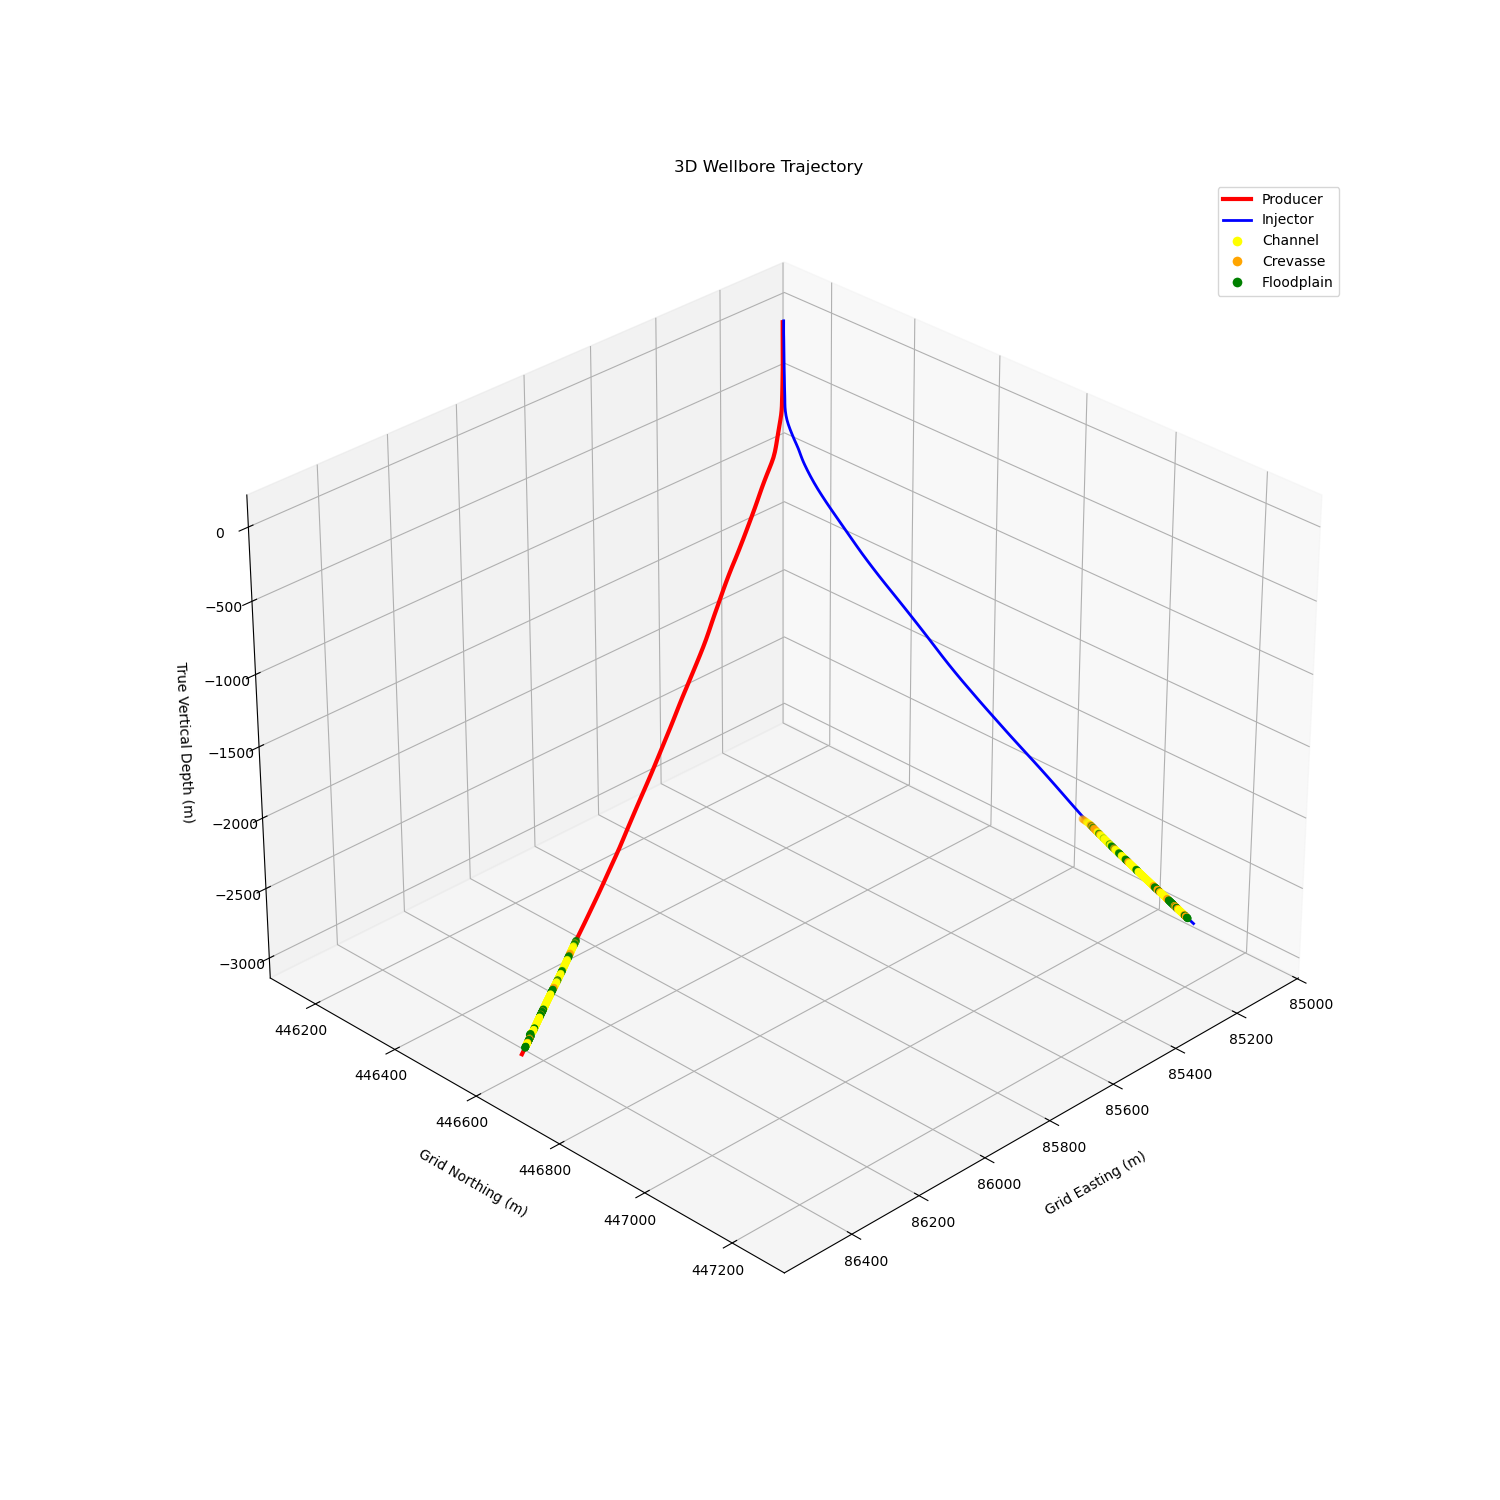

In [16]:
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

for i in range(len(entire_well)):
    plot_3d_wells(ax, entire_well[i], well_names[i], well_colors[i], well_thicknesses[i])
    plot_3d_facies(ax, reservoir_sections[i], facies_association["facies_colors"])

ax.set_xlabel('Grid Easting (m)', labelpad=15)
ax.set_ylabel('Grid Northing (m)', labelpad=15)
ax.set_zlabel('True Vertical Depth (m)', labelpad=10)
ax.set_title('3D Wellbore Trajectory')

handles, labels = ax.get_legend_handles_labels()

for val, name in facies_association["facies_names"].items():
    color = facies_association["facies_colors"][val]
    custom_marker = Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=name)
    handles.append(custom_marker)

ax.legend(handles=handles, loc='best')
ax.view_init(elev=30, azim=45, roll=0)
plt.show();

## 4. Main excecution block Pyvista

### 3D reservoir with wells

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\mathi\miniconda3\envs\flumy_environment\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x000002A6F8603700> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\mathi\miniconda3\envs\flumy_environment\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x000002A6F8603700> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "c:\Users\mathi\miniconda3\envs\flumy_environment\Lib\asyncio\events.py", line 84, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter contex

Widget(value='<iframe src="http://localhost:60094/index.html?ui=P_0x2a681d44b50_0&reconnect=auto" class="pyvis…

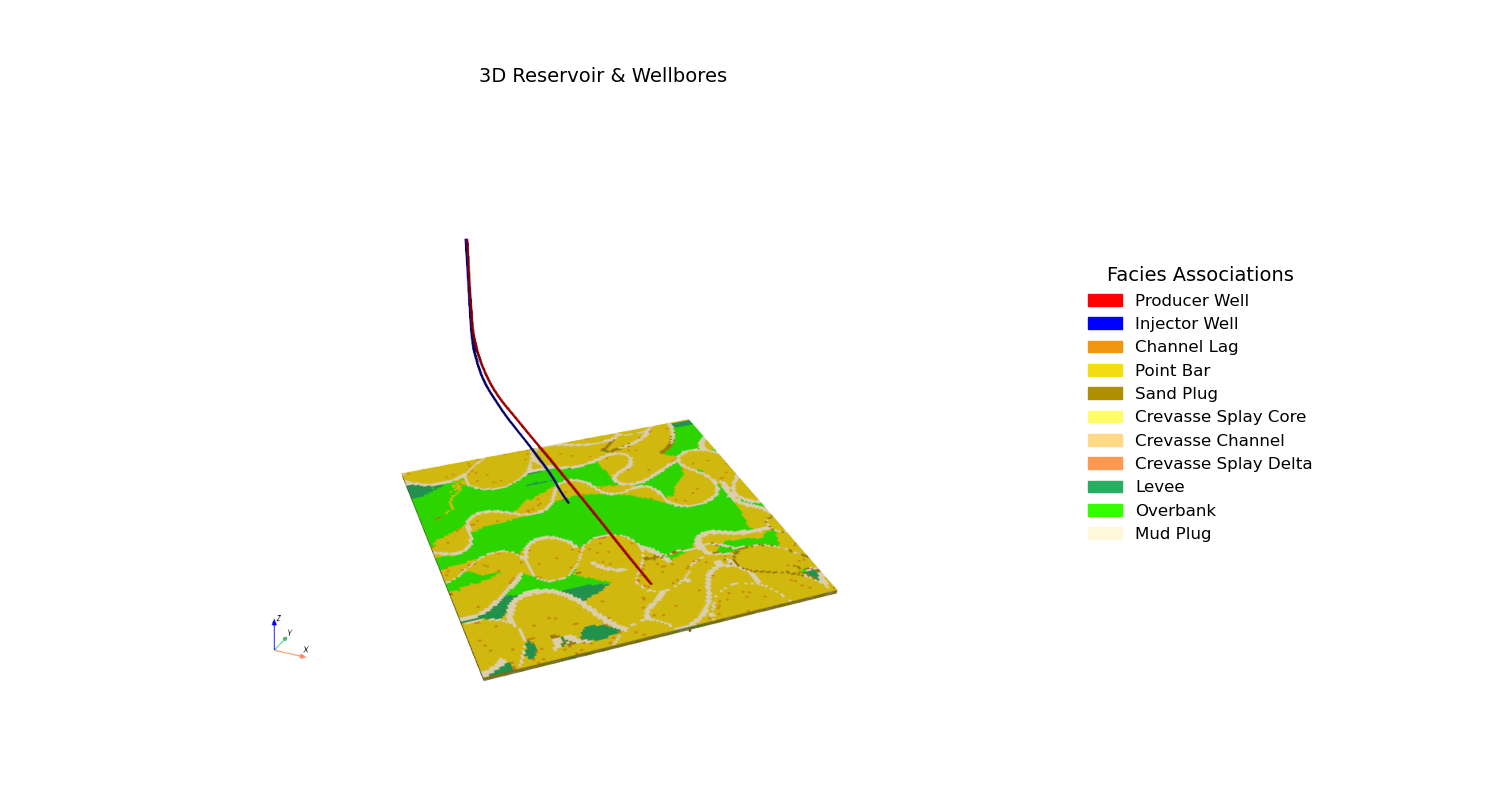

Exception raised
AttributeError("'NoneType' object has no attribute 'GetMouseWheelMotionFactor'")
Traceback (most recent call last):
  File "c:\Users\mathi\miniconda3\envs\flumy_environment\Lib\site-packages\wslink\protocol.py", line 317, in onCompleteMessage
    results = func(*args, **kwargs)
              ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mathi\miniconda3\envs\flumy_environment\Lib\site-packages\trame_vtk\modules\vtk\protocols\mouse_handler.py", line 124, in update_zoomFromWheel
    prev_motion_factor = style.GetMouseWheelMotionFactor()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'NoneType' object has no attribute 'GetMouseWheelMotionFactor'

Exception raised
AttributeError("'NoneType' object has no attribute 'GetMouseWheelMotionFactor'")
Traceback (most recent call last):
  File "c:\Users\mathi\miniconda3\envs\flumy_environment\Lib\site-packages\wslink\protocol.py", line 317, in onCompleteMessage
    results = func(*args, **kwargs)
              ^^

In [ ]:
def main():
    unique_facies = np.unique(training_sample_3d)
    fig = plt.figure(figsize=(15, 8))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 0.5], wspace=0.1)
    
    ax_main = fig.add_subplot(gs[0, 0])    
    ax_leg = fig.add_subplot(gs[0, 1]) 
    
    ax_main.axis('off') # Hide axes for the image
    ax_leg.axis('off')  # Hide axes for the legend


    plotter = pv.Plotter(off_screen=True)
    
    shifts = (86237.00 - 1900, 446550.00 - 800, -2570.00)
    
    # Add Reservoir (Assumes function from previous step is defined)
    mesh, kwargs = build_reservoir_mesh(
        training_sample_3d, 
        facies_cmap, clim_min, clim_max, facies_annotations, 
        rotation_angle=-45
    )
    kwargs.pop('scalar_bar_args', None) 
    kwargs['show_scalar_bar'] = False
    
    plotter.add_mesh(mesh, **kwargs)
    
    add_wellbore(plotter, DEL_GT_01, shifts, color='red', label_name="Producer")
    add_wellbore(plotter, DEL_GT_02, shifts, color='blue', label_name="Injector")
    
    set_camera_and_render(plotter) # Ensure this doesn't call plotter.show() anymore!
    
    img = plotter.screenshot(transparent_background=True, return_img=True)

    ax_main.imshow(img)
    ax_main.set_title("3D Reservoir & Wellbores", fontsize=14, pad=10)


    legend_patches = []
    
    legend_patches.append(mpatches.Patch(color='red', label='Producer Well'))
    legend_patches.append(mpatches.Patch(color='blue', label='Injector Well'))
    

    sorted_facies = sorted(config_flumy_facies.values(), key=lambda x: x['val'])
    for f_props in sorted_facies:
        if f_props['val'] in unique_facies:
            name = facies_annotations.get(f_props['val'], "Unknown")
            hex_color = f_props['color']
            legend_patches.append(mpatches.Patch(color=hex_color, label=name))
    
    ax_leg.legend(handles=legend_patches, loc='center left', fontsize=12, frameon=False, title="Facies Associations", title_fontsize=14)
    plotter.close()


if __name__ == "__main__":
    main()

## 5. Visualize Reservoir sections normalized

In [20]:
def adjust_MD(df_1, df_2):
    df_1_copy = df_1.copy()
    df_2_copy = df_2.copy()
    
    abs_difference = np.abs(df_1['MD'].iloc[0] - df_2['MD'].iloc[0])

    df_1_copy['MD'] = df_1_copy['MD'] - abs_difference
    
    return df_1_copy, df_2_copy


facies_DEL_GT_01_add, facies_DEL_GT_02_add = adjust_MD(facies_DEL_GT_01, facies_DEL_GT_02)
print(facies_DEL_GT_01_add)

     Well_ID    MD     GRID N    GRID E  Facies 
0    Well_01  2223  446550.37  86237.25        3
1    Well_01  2224  446550.61  86238.03        3
2    Well_01  2225  446550.85  86238.81        3
3    Well_01  2226  446551.08  86239.59        3
4    Well_01  2227  446551.32  86240.37        3
..       ...   ...        ...       ...      ...
336  Well_01  2559  446623.05  86477.99        3
337  Well_01  2560  446623.27  86478.73        3
338  Well_01  2561  446623.50  86479.47        3
339  Well_01  2562  446623.72  86480.22        3
340  Well_01  2563  446623.94  86480.96        3

[341 rows x 5 columns]


Widget(value='<iframe src="http://localhost:60094/index.html?ui=P_0x2a68abd46d0_0&reconnect=auto" class="pyvis…

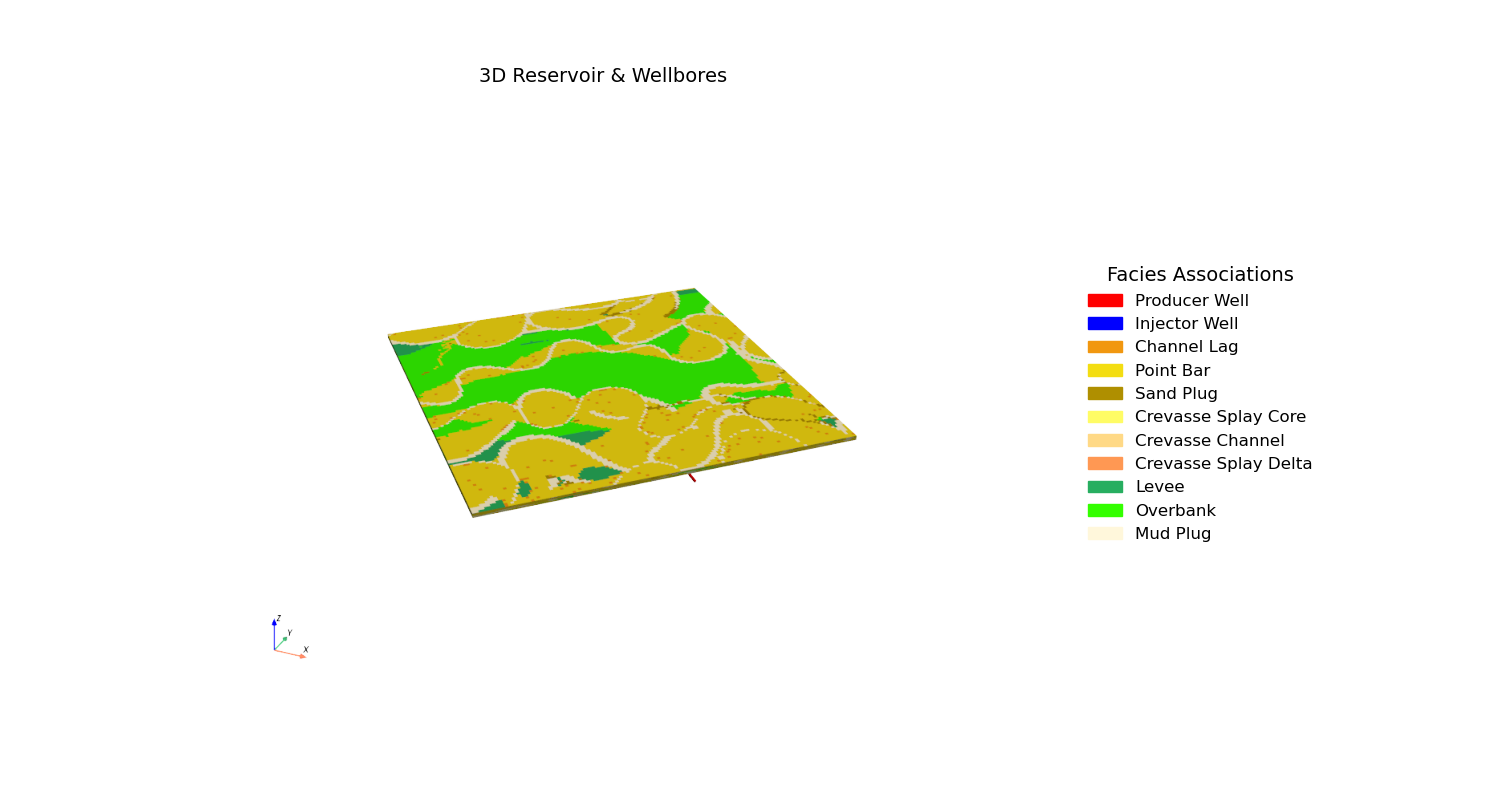

In [19]:
def main():
    unique_facies = np.unique(training_sample_3d)
    fig = plt.figure(figsize=(15, 8))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 0.5], wspace=0.1)
    
    ax_main = fig.add_subplot(gs[0, 0])    
    ax_leg = fig.add_subplot(gs[0, 1]) 
    
    ax_main.axis('off') # Hide axes for the image
    ax_leg.axis('off')  # Hide axes for the legend


    plotter = pv.Plotter(off_screen=True)
    
    shifts = (86237.00 - 1900, 446550.00 - 800, -2223.00)
    
    # Add Reservoir (Assumes function from previous step is defined)
    mesh, kwargs = build_reservoir_mesh(
        training_sample_3d, 
        facies_cmap, clim_min, clim_max, facies_annotations, 
        rotation_angle=-45
    )
    kwargs.pop('scalar_bar_args', None) 
    kwargs['show_scalar_bar'] = False
    
    plotter.add_mesh(mesh, **kwargs)
    
    add_wellbore(plotter, facies_DEL_GT_01_add, shifts, color='red', label_name="Producer")
    add_wellbore(plotter, facies_DEL_GT_02_add, shifts, color='blue', label_name="Injector")
    
    set_camera_and_render(plotter) # Ensure this doesn't call plotter.show() anymore!
    
    img = plotter.screenshot(transparent_background=True, return_img=True)

    ax_main.imshow(img)
    ax_main.set_title("3D Reservoir & Wellbores", fontsize=14, pad=10)


    legend_patches = []
    
    legend_patches.append(mpatches.Patch(color='red', label='Producer Well'))
    legend_patches.append(mpatches.Patch(color='blue', label='Injector Well'))
    

    sorted_facies = sorted(config_flumy_facies.values(), key=lambda x: x['val'])
    for f_props in sorted_facies:
        if f_props['val'] in unique_facies:
            name = facies_annotations.get(f_props['val'], "Unknown")
            hex_color = f_props['color']
            legend_patches.append(mpatches.Patch(color=hex_color, label=name))
    
    ax_leg.legend(handles=legend_patches, loc='center left', fontsize=12, frameon=False, title="Facies Associations", title_fontsize=14)
    plotter.close()


if __name__ == "__main__":
    main()